# 의원 활동 추적 LangGraph 구조 시각화

이 노트북은 `src/member_activity_workflow.py`에 정의된 의원 활동 추적 LangGraph 워크플로우를 Mermaid 그래프로 시각화합니다.


In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys

from IPython.display import Image, Markdown, display
from langgraph.graph.state import CompiledStateGraph


PROJECT_DIR = Path('/home/pck/메타코드 부트캠프/LangGraph _국회챗봇/의원챗봇')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.member_activity_workflow import (  # noqa: E402
    AssemblyAPIClient,
    WORKFLOW_VERSION,
    build_member_activity_graph,
)


/home/pck/메타코드 부트캠프/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass
class NodeStyles:
    default: str = (
        'fill:#45C4B0, fill-opacity:0.3, color:#23260F, '
        'stroke:#45C4B0, stroke-width:1px, font-weight:bold, line-height:1.2'
    )
    first: str = (
        'fill:#45C4B0, fill-opacity:0.1, color:#23260F, '
        'stroke:#45C4B0, stroke-width:1px, font-weight:normal, '
        'font-style:italic, stroke-dasharray:2,2'
    )
    last: str = (
        'fill:#45C4B0, fill-opacity:1, color:#000000, '
        'stroke:#45C4B0, stroke-width:1px, font-weight:normal, '
        'font-style:italic, stroke-dasharray:2,2'
    )


def visualize_graph(graph, xray=False, output_path=None):
    """CompiledStateGraph 객체를 Mermaid PNG로 시각화합니다.

    Args:
        graph: 시각화할 LangGraph 컴파일 그래프.
        xray: True이면 LangGraph 내부 세부 구조까지 표시합니다.
        output_path: PNG 파일로 저장할 경로. None이면 저장하지 않습니다.
    """
    if not isinstance(graph, CompiledStateGraph):
        raise TypeError('graph는 CompiledStateGraph 객체여야 합니다.')

    try:
        png = graph.get_graph(xray=xray).draw_mermaid_png(
            background_color='white',
            node_colors=NodeStyles(),
        )
        if output_path:
            output_file = Path(output_path)
            output_file.write_bytes(png)
            print(f'그래프 PNG 저장 완료: {output_file}')
        display(Image(png))
    except Exception as error:
        print(f'[ERROR] Visualize Graph Error: {error}')
        print('PNG 렌더링이 실패하여 Mermaid 원문을 출력합니다.')
        mermaid_source = graph.get_graph(xray=xray).draw_mermaid()
        display(Markdown(f'```mermaid\n{mermaid_source}\n```'))


## 그래프 빌드

`AssemblyAPIClient`는 그래프 노드 생성에 필요하지만, 아래 셀에서는 실제 API 호출을 하지 않습니다. 따라서 더미 키를 사용합니다.

In [3]:
client = AssemblyAPIClient(api_key='dummy')
member_activity_app = build_member_activity_graph(client)

print(f'workflow version: {WORKFLOW_VERSION}')
print(type(member_activity_app).__name__)


workflow version: member_activity_v22_vote_timeout_mitigation
CompiledStateGraph


## 기본 그래프 시각화

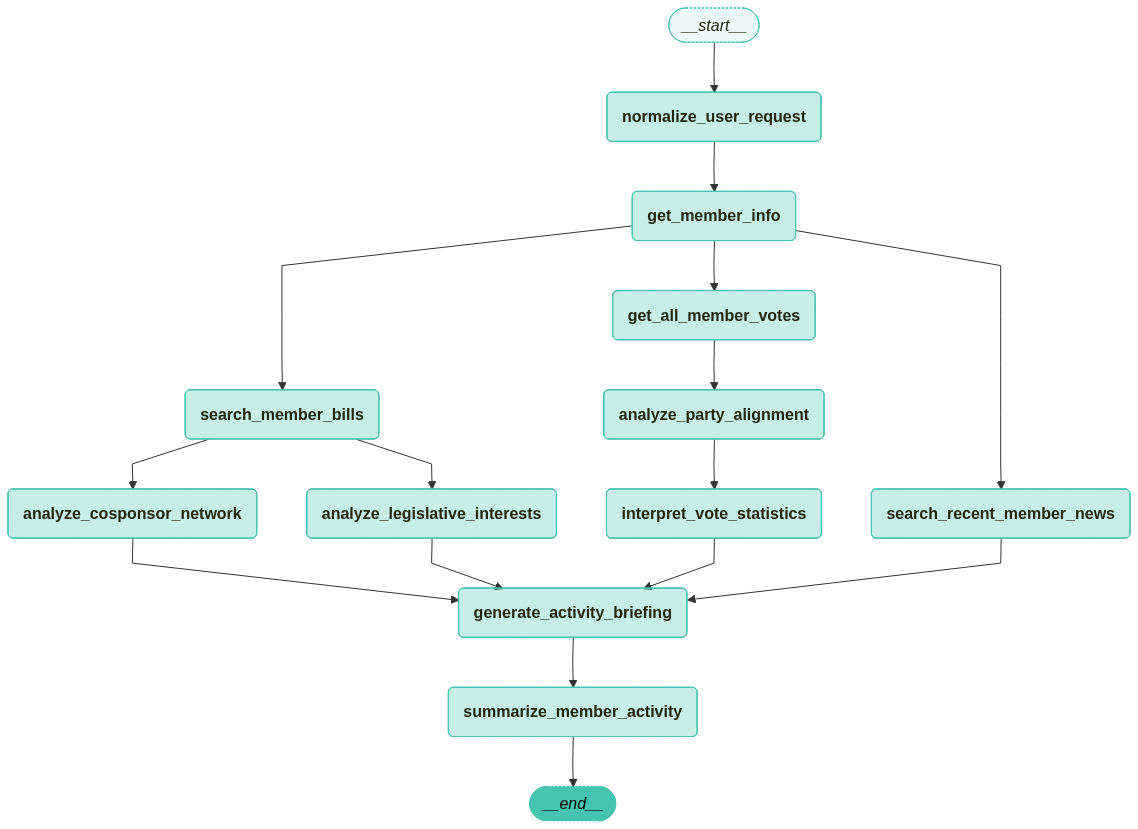

In [4]:
visualize_graph(member_activity_app)


## PNG 파일로 저장하기

필요하면 아래 셀의 주석을 해제해 `assets` 폴더에 그래프 이미지를 저장할 수 있습니다.

In [ ]:
# output_path = PROJECT_DIR / 'assets' / 'member_activity_langgraph.png'
# visualize_graph(member_activity_app, output_path=output_path)
